In [1]:
import numpy as np
import matplotlib.pyplot as plt
import graph_style as gs
gs.set_graph_style(1)

Text(0, 0.5, 'Probability Density')

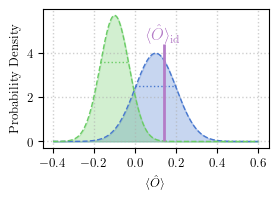

In [31]:
def gaussian(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma)**2)
def h_line(x, y, mu, sigma):
    """ plot hline signifying the sigma of the gaussian """
    x_minus = mu - sigma
    x_plus = mu + sigma
    y = gaussian(mu, mu, sigma)*(1-1/np.e)  # height of the line is 1/e of the peak
    return x_minus, x_plus, y

x_arr = np.linspace(-0.4, 0.6, 10000)
x1 = 0.1
sigma1 = 0.1
x2 = -0.1
sigma2 = 0.07
g1 = gaussian(x_arr, x1, sigma1)
g2 = gaussian(x_arr, x2, sigma2)

h1 = h_line(x_arr, g1, x1, sigma1)
h2 = h_line(x_arr, g2, x2, sigma2)


fig_width = gs.get_fig_width()/2
fig_height = fig_width / 1.618
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.plot(x_arr, g1, color=gs.get_color(0), label='Gaussian 1')
ax.plot(x_arr, g2, color=gs.get_color(1), label='Gaussian 2')
ax.hlines(h1[2], h1[0], h1[1], color=gs.get_color(0), label='$\\sigma_1$', linewidth=1, linestyle='dotted')
ax.hlines(h2[2], h2[0], h2[1], color=gs.get_color(1), label='$\\sigma_2$', linewidth=1, linestyle='dotted')

vx = x1*1.4
vy =4.4
ax.vlines(vx, 0, vy, color=gs.get_color(3), label='$\\langle \\hat O \\rangle_{\\rm id}$', linewidth=2)
label = "$\\langle \\hat O \\rangle_{\\rm id}$"
ax.text(vx, vy+.25, label, color=gs.get_color(3), fontsize=12, ha='center')
ax.fill_between(x_arr, g1, color=gs.get_color(0), alpha=0.3)
ax.fill_between(x_arr, g2, color=gs.get_color(1), alpha=0.3)
ax.set_xlabel('$\\langle \\hat O \\rangle$')
ax.set_ylabel('Probability Density')

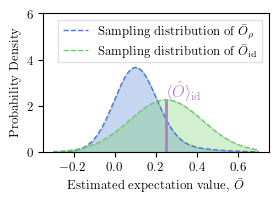

In [3]:
def gaussian(x, mu, sigma):
    return 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma)**2)
def h_line(x, y, mu, sigma):
    """ plot hline signifying the sigma of the gaussian """
    x_minus = mu - sigma
    x_plus = mu + sigma
    y = gaussian(mu, mu, sigma)*(1-1/np.e)  # height of the line is 1/e of the peak
    return x_minus, x_plus, y

x_arr = np.linspace(-0.3, 0.7, 10000)
p_s = 0.1
N = 10000
N_s = int(p_s*N)
N_err = N-N_s
var_s = 1/np.sqrt(N_s)
var_err = 1/np.sqrt(N_err)
x1 = 0.25
sigma1 = np.sqrt(var_s)
x2 = 0.1
sigma2 = np.sqrt(var_err)
gid = gaussian(x_arr, x1, sigma1)
gerr = gaussian(x_arr, x2, sigma2)

g1 = p_s*gid+(1-p_s)*gerr
g2 = p_s*gid

# make dist PDFs
def make_pdf(x_arr, g):
    dx = x_arr[1]-x_arr[0]
    pdf = g/np.sum(g*dx)
    return pdf
pdf1 = make_pdf(x_arr, g1)
pdf2 = make_pdf(x_arr, g2)


fig_width = gs.get_fig_width()/2
fig_height = fig_width / 1.618
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.plot(x_arr, pdf1, color=gs.get_color(0), label='Sampling distribution of $\\bar O_\\rho$')
ax.plot(x_arr, pdf2, color=gs.get_color(1), label='Sampling distribution of $\\bar O_{\\rm id}$')

vx = x1
vy = np.max(pdf2)
ax.vlines(vx, 0, vy, color=gs.get_color(3),  linewidth=2)
label = "$\\langle \\hat O \\rangle_{\\rm id}$"
ax.text(vx+0.09, vy+.18, label, color=gs.get_color(3), fontsize=12, ha='center')
ax.fill_between(x_arr, pdf1, color=gs.get_color(0), alpha=0.3)
ax.fill_between(x_arr, pdf2, color=gs.get_color(1), alpha=0.3)
ax.set_xlabel('Estimated expectation value, $\\bar O $')
ax.set_ylabel('Probability Density')
ax.set_ylim(0, 6.0)
# make log scale
# ax.set_yscale('log')
ax.legend(loc='upper right', fontsize=9)
ax.grid(False)
f_name = '..\\..\\pdf_figure\\ch6\\qem_schem.pdf'
plt.savefig(f_name, bbox_inches='tight')